<a href="https://colab.research.google.com/github/tanisha1402/Machine-Learning-Practice/blob/main/Extras/Dataset_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Uploading all the datasets
df = pd.read_csv("/content/hh_demographic.csv")
trans = pd.read_csv("/content/project_transactions.csv")
prod = pd.read_csv("/content/product.csv")

In [ ]:
df.head()

,AGE_DESC,MARITAL_STATUS_CODE,INCOME_DESC,HOMEOWNER_DESC,HH_COMP_DESC,HOUSEHOLD_SIZE_DESC,KID_CATEGORY_DESC,household_key
0,65+,A,35-49K,Homeowner,2 Adults No Kids,2,None/Unknown,1
1,45-54,A,50-74K,Homeowner,2 Adults No Kids,2,None/Unknown,7
2,25-34,U,25-34K,Unknown,2 Adults Kids,3,1,8
3,25-34,U,75-99K,Homeowner,2 Adults Kids,4,2,13
4,45-54,B,50-74K,Homeowner,Single Female,1,None/Unknown,16


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   AGE_DESC             801 non-null    object
 1   MARITAL_STATUS_CODE  801 non-null    object
 2   INCOME_DESC          801 non-null    object
 3   HOMEOWNER_DESC       801 non-null    object
 4   HH_COMP_DESC         801 non-null    object
 5   HOUSEHOLD_SIZE_DESC  801 non-null    object
 6   KID_CATEGORY_DESC    801 non-null    object
 7   household_key        801 non-null    int64 
dtypes: int64(1), object(7)
memory usage: 50.2+ KB


In [ ]:
df.describe()

,household_key
count,801.000000
mean,1235.176030
std,736.804647
min,1.000000
25%,596.000000
50%,1218.000000
75%,1914.000000
max,2499.000000


In [ ]:
df.isnull().sum()

,0
AGE_DESC,0
MARITAL_STATUS_CODE,0
INCOME_DESC,0
HOMEOWNER_DESC,0
HH_COMP_DESC,0
HOUSEHOLD_SIZE_DESC,0
KID_CATEGORY_DESC,0
household_key,0


In [ ]:
# Shape of the DataFrame before removing duplicates
df.shape

(801, 8)

In [ ]:
# Number of duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

In [ ]:
# If duplicates exist, remove them and reset the index
if df.duplicated().sum() > 0:
    df = df.drop_duplicates().reset_index(drop=True)

# Shape of the DataFrame after removing duplicates
df.shape

(801, 8)

In [ ]:
# Identify categorical columns in the dataframe
categorical_cols = df.select_dtypes(include=['object']).columns

In [ ]:
# Showing which columns are categorical
print(list(categorical_cols))

['AGE_DESC', 'MARITAL_STATUS_CODE', 'INCOME_DESC', 'HOMEOWNER_DESC', 'HH_COMP_DESC', 'HOUSEHOLD_SIZE_DESC', 'KID_CATEGORY_DESC']


In [ ]:
for col in categorical_cols:
    print(f"\nUnique values and counts for '{col}':")
    print(df[col].value_counts())


Unique values and counts for 'AGE_DESC':
AGE_DESC
45-54    288
35-44    194
25-34    142
65+       72
55-64     59
19-24     46
Name: count, dtype: int64

Unique values and counts for 'MARITAL_STATUS_CODE':
MARITAL_STATUS_CODE
U    344
A    340
B    117
Name: count, dtype: int64

Unique values and counts for 'INCOME_DESC':
INCOME_DESC
50-74K       192
35-49K       172
75-99K        96
25-34K        77
15-24K        74
Under 15K     61
125-149K      38
100-124K      34
150-174K      30
250K+         11
175-199K      11
200-249K       5
Name: count, dtype: int64

Unique values and counts for 'HOMEOWNER_DESC':
HOMEOWNER_DESC
Homeowner          504
Unknown            233
Renter              42
Probable Renter     11
Probable Owner      11
Name: count, dtype: int64

Unique values and counts for 'HH_COMP_DESC':
HH_COMP_DESC
2 Adults No Kids    255
2 Adults Kids       187
Single Female       144
Single Male          95
Unknown              73
1 Adult Kids         47
Name: count, dtype: int64

In [ ]:
# Missing values in trans DataFrame
print(trans.isnull().sum())

household_key        0
BASKET_ID            0
DAY                  0
PRODUCT_ID           0
QUANTITY             0
SALES_VALUE          0
STORE_ID             0
RETAIL_DISC          0
WEEK_NO              0
COUPON_DISC          0
COUPON_MATCH_DISC    0
dtype: int64


In [ ]:
# Checking the shape of the trans DataFrame before removing duplicates
print(trans.shape)

(2146311, 11)


In [ ]:
# Counting how many duplicate rows exist in trans
duplicate_rows_trans = trans.duplicated().sum()
print(duplicate_rows_trans)

0


In [ ]:
# If duplicates exist, drop them and reset the index
if duplicate_rows_trans > 0:
    trans = trans.drop_duplicates().reset_index(drop=True)

    # Show the shape of the DataFrame after dropping duplicates
    print(trans.shape)

In [ ]:
# List of identifier columns to analyze
identifier_cols = ['household_key', 'BASKET_ID', 'PRODUCT_ID', 'STORE_ID']
total_rows = len(trans)

In [ ]:
# Loop through each identifier column to inspect uniqueness and frequency
for col in identifier_cols:
# Showing which column is being analyzed
    print(f"\nColumn: {col}")

    # Total number of rows in the DataFrame
    print(total_rows)

    # Number of unique values in the column
    print(trans[col].nunique())

    # Top 5 most frequent values in the column
    print(trans[col].value_counts().head())


Column: household_key
2146311
2099
household_key
718     6851
1609    6625
1111    6576
1453    6561
982     5806
Name: count, dtype: int64

Column: BASKET_ID
2146311
232939
BASKET_ID
33347880492    161
33655186256    155
28210676830    150
41560100381    147
33094862148    146
Name: count, dtype: int64

Column: PRODUCT_ID
2146311
84138
PRODUCT_ID
1082185    24515
6534178    16619
1029743    11935
995242     10264
1106523     8098
Name: count, dtype: int64

Column: STORE_ID
2146311
526
STORE_ID
367      63921
406      41075
381      38107
31782    37906
361      37135
Name: count, dtype: int64


In [ ]:
print("Rows with QUANTITY <= 0 or SALES_VALUE <= 0:")
print(trans[(trans['QUANTITY'] <= 0) | (trans['SALES_VALUE'] <= 0)].head())

Rows with QUANTITY <= 0 or SALES_VALUE <= 0:
     household_key    BASKET_ID  DAY  PRODUCT_ID  QUANTITY  SALES_VALUE  \
86             744  26985165432    1     5978648         0          0.0   
117           1287  26985336468    1     5978648         0          0.0   
250            271  26997082949    2     5978656         0          0.0   
583            315  27008952267    3      957951         0          0.0   
823            568  27021090189    4      951412         1          0.0   

     STORE_ID  RETAIL_DISC  WEEK_NO  COUPON_DISC  COUPON_MATCH_DISC  
86      31582         0.00        1          0.0                0.0  
117       304         0.00        1          0.0                0.0  
250       329         0.00        1         -2.0                0.0  
583       327         0.00        1          0.0                0.0  
823       446        -1.48        1          0.0                0.0  


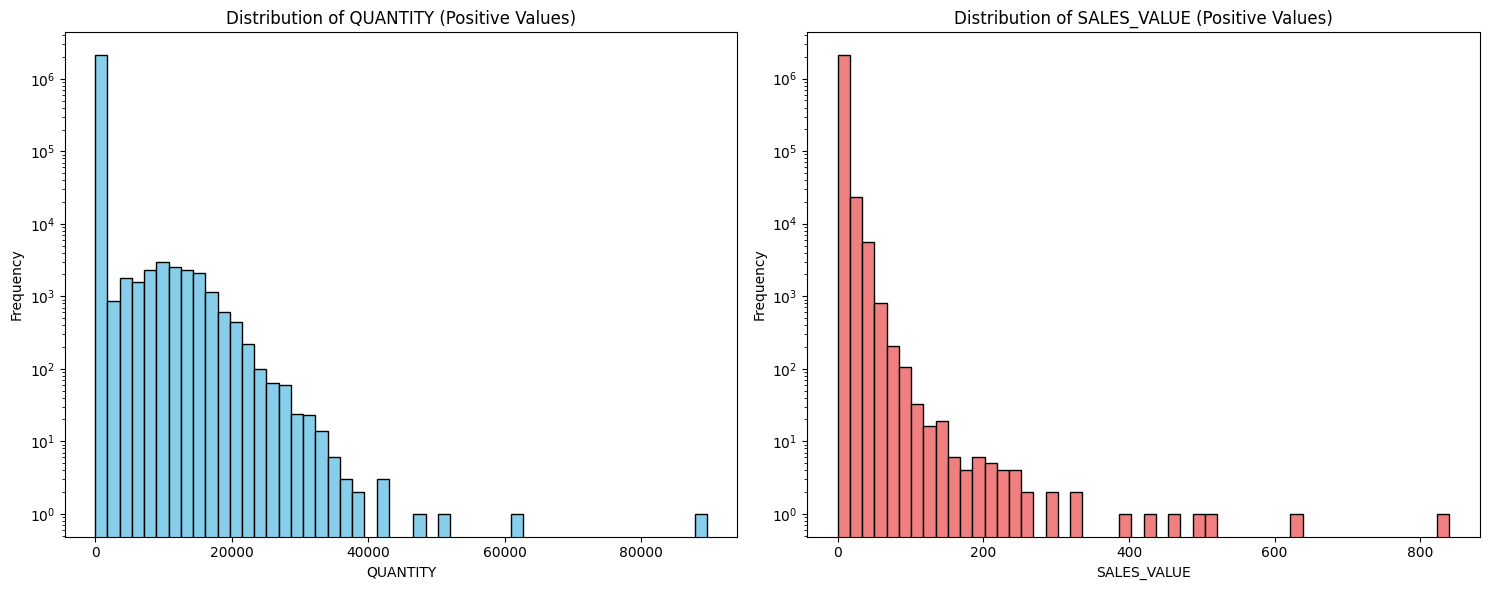

In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.hist(trans[trans['QUANTITY'] > 0]['QUANTITY'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of QUANTITY (Positive Values)')
plt.xlabel('QUANTITY')
plt.ylabel('Frequency')
plt.yscale('log') # Use log scale for frequency to better visualize spread

plt.subplot(1, 2, 2)
plt.hist(trans[trans['SALES_VALUE'] > 0]['SALES_VALUE'], bins=50, color='lightcoral', edgecolor='black')
plt.title('Distribution of SALES_VALUE (Positive Values)')
plt.xlabel('SALES_VALUE')
plt.ylabel('Frequency')
plt.yscale('log') # Use log scale for frequency to better visualize spread

plt.tight_layout()
plt.show()


In [ ]:
discount_cols = ['RETAIL_DISC', 'COUPON_DISC', 'COUPON_MATCH_DISC']
print("Descriptive statistics for discount columns:")
print(trans[discount_cols].describe())

Descriptive statistics for discount columns:
        RETAIL_DISC   COUPON_DISC  COUPON_MATCH_DISC
count  2.146311e+06  2.146311e+06       2.146311e+06
mean  -5.333568e-01 -1.579855e-02      -2.805633e-03
std    1.229413e+00  2.121266e-01       3.924693e-02
min   -1.300200e+02 -5.593000e+01      -7.700000e+00
25%   -6.800000e-01  0.000000e+00       0.000000e+00
50%    0.000000e+00  0.000000e+00       0.000000e+00
75%    0.000000e+00  0.000000e+00       0.000000e+00
max    3.990000e+00  0.000000e+00       0.000000e+00


In [ ]:
print("Rows with positive discount values:")
print(trans[(trans['RETAIL_DISC'] > 0) | (trans['COUPON_DISC'] > 0) | (trans['COUPON_MATCH_DISC'] > 0)].head())

Rows with positive discount values:
        household_key    BASKET_ID  DAY  PRODUCT_ID  QUANTITY  SALES_VALUE  \
799232           1306  31624096856  310      990941         0         0.01   
825593           1306  31735306143  318     7409789         0         0.00   
843434           1321  31803641901  323     1051069         0         0.00   
843435           1321  31803641901  323     1055863         0         0.00   
879663             37  31944616637  334     8090539         0         0.00   

        STORE_ID   RETAIL_DISC  WEEK_NO  COUPON_DISC  COUPON_MATCH_DISC  
799232       340  1.000000e-02       45          0.0                0.0  
825593       381  2.220446e-16       46          0.0                0.0  
843434       364  5.551115e-17       47          0.0                0.0  
843435       364  5.551115e-17       47          0.0                0.0  
879663       381  2.220446e-16       48          0.0                0.0  


In [ ]:
print(f"Min DAY: {trans['DAY'].min()}, Max DAY: {trans['DAY'].max()}")
print(f"Min WEEK_NO: {trans['WEEK_NO'].min()}, Max WEEK_NO: {trans['WEEK_NO'].max()}")

Min DAY: 1, Max DAY: 711
Min WEEK_NO: 1, Max WEEK_NO: 102


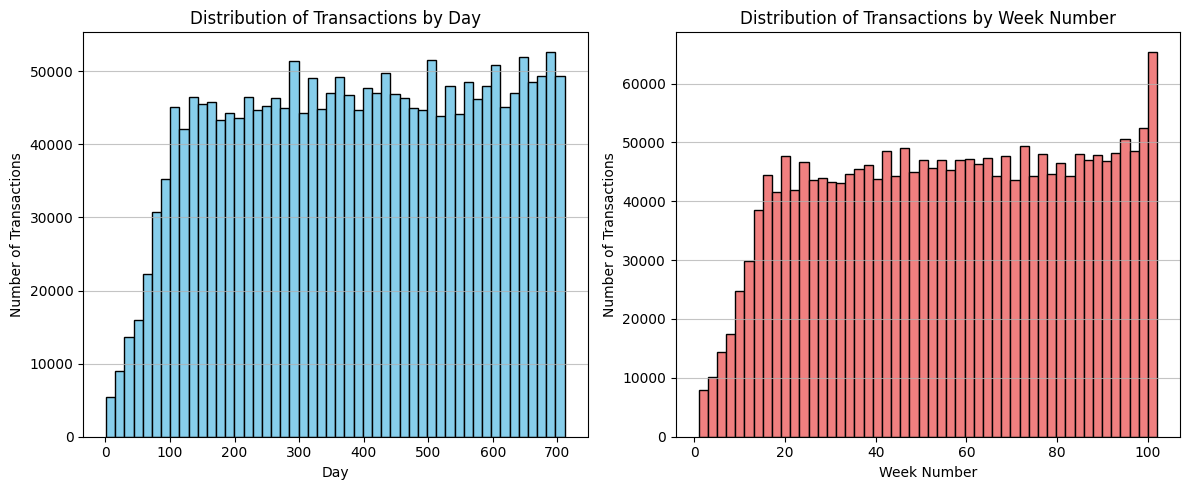

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(trans['DAY'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Transactions by Day')
plt.xlabel('Day')
plt.ylabel('Number of Transactions')
plt.grid(axis='y', alpha=0.75)

plt.subplot(1, 2, 2)
plt.hist(trans['WEEK_NO'], bins=50, color='lightcoral', edgecolor='black')
plt.title('Distribution of Transactions by Week Number')
plt.xlabel('Week Number')
plt.ylabel('Number of Transactions')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

In [ ]:
print(prod.head())
prod.info()
print(prod.describe())

   PRODUCT_ID  MANUFACTURER    DEPARTMENT     BRAND            COMMODITY_DESC  \
0       25671             2       GROCERY  National                  FRZN ICE   
1       26081             2  MISC. TRANS.  National  NO COMMODITY DESCRIPTION   
2       26093            69        PASTRY   Private                     BREAD   
3       26190            69       GROCERY   Private      FRUIT - SHELF STABLE   
4       26355            69       GROCERY   Private             COOKIES/CONES   

            SUB_COMMODITY_DESC CURR_SIZE_OF_PRODUCT  
0          ICE - CRUSHED/CUBED                22 LB  
1  NO SUBCOMMODITY DESCRIPTION                       
2         BREAD:ITALIAN/FRENCH                       
3                  APPLE SAUCE                50 OZ  
4            SPECIALTY COOKIES                14 OZ  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92353 entries, 0 to 92352
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                ----

In [ ]:
# Missing values in prod DataFrame
print(prod.isnull().sum())

PRODUCT_ID              0
MANUFACTURER            0
DEPARTMENT              0
BRAND                   0
COMMODITY_DESC          0
SUB_COMMODITY_DESC      0
CURR_SIZE_OF_PRODUCT    0
dtype: int64


In [ ]:
# Check the shape of the prod DataFrame before removing duplicates
print(prod.shape)

(92353, 7)


In [ ]:
# Count how many duplicate rows exist in prod
duplicate_rows_prod = prod.duplicated().sum()
print(duplicate_rows_prod)

0


In [ ]:
# If there are duplicates, drop them and reset the index
if duplicate_rows_prod > 0:
    prod = prod.drop_duplicates().reset_index(drop=True)

    # Show the shape of the DataFrame after dropping duplicates
    print(prod.shape)

In [ ]:
# Identify categorical columns in the prod DataFrame
categorical_cols_prod = prod.select_dtypes(include=['object']).columns
# Show which columns are categorical
print(list(categorical_cols_prod))

['DEPARTMENT', 'BRAND', 'COMMODITY_DESC', 'SUB_COMMODITY_DESC', 'CURR_SIZE_OF_PRODUCT']


In [ ]:
# Loop through each categorical column to inspect unique values and counts
for col in categorical_cols_prod:
    # Indicating which column is being analyzed
    print(f"\nColumn: {col}")

    # Showing the unique values and their counts
    print(prod[col].value_counts())


Column: DEPARTMENT
DEPARTMENT
GROCERY            39021
DRUG GM            31529
PRODUCE             3118
COSMETICS           3011
NUTRITION           2914
MEAT                2544
MEAT-PCKGD          2427
DELI                2354
PASTRY              2149
FLORAL               938
SEAFOOD-PCKGD        563
MISC. TRANS.         490
SPIRITS              377
SEAFOOD              369
GARDEN CENTER        128
RESTAURANT           102
MISC SALES TRAN       88
SALAD BAR             48
COUP/STR & MFG        39
TRAVEL & LEISUR       28
FROZEN GROCERY        23
KIOSK-GAS             16
                      15
CHEF SHOPPE           14
RX                     9
CNTRL/STORE SUP        4
TOYS                   3
GM MERCH EXP           3
POSTAL CENTER          3
VIDEO RENTAL           3
DAIRY DELI             3
GRO BAKERY             2
VIDEO                  2
CHARITABLE CONT        2
PROD-WHS SALES         2
DELI/SNACK BAR         2
AUTOMOTIVE             2
PHOTO                  2
ELECT &PLUMBING    

In [ ]:
# Show the number of unique PRODUCT_IDs
print(prod['PRODUCT_ID'].nunique())

92353


In [ ]:
# Show the number of unique MANUFACTURERs
print(prod['MANUFACTURER'].nunique())

6476


In [ ]:
# Display the top 10 most frequent MANUFACTURER values
print(prod['MANUFACTURER'].value_counts().head(10))

MANUFACTURER
69      12676
2        1411
5423     1376
764      1332
1407     1210
693       979
544       915
5143      771
1046      717
1251      685
Name: count, dtype: int64
